In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Pittsburgh's Best Neighborhood Combined Analysis

**Team:** Lucky Number Seven

---

## Introduction

Our team defined the "best" neighborhood in Pittsburgh as one that balances three different metrics from **quality of life, safety to accessibility**. 

Using the following datasets: <br>
[City of Pittsburgh Parks](https://data.wprdc.org/dataset/parks1) | <br>
[Pittsburgh Police Arrests 2024–2026](https://data.wprdc.org/dataset/pbp_arrest_data_2024_2025) | <br>
[Pittsburgh Regional Transit Stops](https://data.wprdc.org/dataset/prt-of-allegheny-county-transit-stops) | <br>

This notebook combines all three sub-metrics into a single ranking and names the overall best neighborhood in Pittsburgh.

## Method

Each sub-metric is normalized to a 0-1 scale (1 being best and 0 being worst). To get a single overall score per neighborhood, we average the three sub-metric scores with equal weights:

$$\text{overall score} = \frac{1}{3}(\text{green} + \text{safety} + \text{accessibility})$$

In [23]:
#quality scores
green = pd.read_csv('green_space_scores_by_neighborhood.csv')
print(f'Green-space scores: {len(green)} neighborhoods')

#accessibility scores


Green-space scores: 79 neighborhoods


In [3]:
#safety scores
safety = pd.read_csv('safety_scores.csv')
print(f'Safety scores: {len(safety)} neighborhoods')

name_fixes = {'St. Clair': 'Saint Clair', 'Southshore': 'South Shore', 'Lincoln–Lemington–Belmar': 'Lincoln-Lemington-Belmar',
    'Spring Hill–City View': 'Spring Hill-City View',}
safety['neighborhood'] = safety['neighborhood'].replace(name_fixes)

safety_clean = (safety.groupby('neighborhood', as_index = False)['arrest_count'].sum())

min_arr = safety_clean['arrest_count'].min()
max_arr = safety_clean['arrest_count'].max()
safety_clean['safety_score'] = (1 - (safety_clean['arrest_count'] - min_arr) / (max_arr - min_arr)).round(3)

safety_clean = safety_clean.sort_values('safety_score', ascending = False).reset_index(drop = True)
safety_clean.head()

Safety scores: 95 neighborhoods


,neighborhood,arrest_count,safety_score
0,Chartiers City,4,1.000
1,Swisshelm Park,17,0.998
2,Ridgemont,17,0.998
3,Chartiers,23,0.997
4,Regent Square,24,0.997


## Merge All Three Sub-Metrics


In [12]:
#merge safety
combined = safety_clean[['neighborhood', 'safety_score']].copy()

#merge green space
combined = combined.merge(green[['neighborhood', 'green_score', 'divname']], on='neighborhood', how='outer')
#merge acc
combined = combined.merge(green[['neighborhood', 'green_score', 'divname']], on='neighborhood', how='outer')


print(f'Combined table: {len(combined)} neighborhoods')
combined.head(10)

Combined table: 91 neighborhoods


,neighborhood,safety_score,green_score,divname
0,Allegheny Center,0.925,0.044,Riverview
1,Allegheny West,0.987,0.044,Riverview
2,Allentown,0.916,1.000,McKinley
3,Arlington,0.971,1.000,McKinley
4,Arlington Heights,0.984,1.000,McKinley
5,Banksville,0.976,0.000,Emerald
6,Bedford Dwellings,0.918,NaN,NaN
7,Beechview,0.936,0.000,Emerald
8,Beltzhoover,0.961,1.000,McKinley
9,Bloomfield,0.929,0.205,Schenley


In [14]:
score_cols = ['safety_score', 'green_score']
for col in score_cols:
    n_have = combined[col].notna().sum()
    print(f'{col:20s}: {n_have} / {len(combined)} neighborhoods have a score')

safety_score        : 91 / 91 neighborhoods have a score
green_score         : 79 / 91 neighborhoods have a score


## Compute the Overall Score 

To Find "Best" Neighborhood by averaging the sub-metric scores per neighborhood. Neighborhoods missing one or more scores are averaged over only the scores they do have.

In [15]:
available_cols = [c for c in score_cols if combined[c].notna().any()]

combined['n_metrics'] = combined[available_cols].notna().sum(axis = 1)
combined['overall_score'] = combined[available_cols].mean(axis = 1, skipna = True)

# For a fair final ranking, only include neighborhoods that have ALL available metrics
max_metrics = combined['n_metrics'].max()
ranked = combined[combined['n_metrics'] == max_metrics].copy()
ranked = ranked.sort_values('overall_score', ascending = False).reset_index(drop = True)

print(f'Ranking based on {max_metrics} sub-metrics, across {len(ranked)} neighborhoods.')
ranked.head(15)

Ranking based on 2 sub-metrics, across 79 neighborhoods.


,neighborhood,safety_score,green_score,divname,n_metrics,overall_score
0,Saint Clair,0.997,1.0,McKinley,2,0.9985
1,New Homestead,0.996,1.0,McKinley,2,0.9980
2,Mount Oliver,0.993,1.0,McKinley,2,0.9965
3,Hays,0.988,1.0,McKinley,2,0.9940
4,Arlington Heights,0.984,1.0,McKinley,2,0.9920
5,Lincoln Place,0.977,1.0,McKinley,2,0.9885
6,Bon Air,0.974,1.0,McKinley,2,0.9870
7,Arlington,0.971,1.0,McKinley,2,0.9855
8,South Shore,0.971,1.0,McKinley,2,0.9855
9,Overbrook,0.969,1.0,McKinley,2,0.9845


## The Best Neighborhood

In [20]:
winner = ranked.iloc[0]
print(f"Best Neighborhood: {winner['neighborhood']}")
print()
print(f"metrics:")
print(f"Overall score: {winner['overall_score']:.2f}")
print(f"Safety score: {winner['safety_score']:.2f}")
print(f"Green space score: {winner['green_score']:.2f}")
#print(f"Accessibility score: {winner['accessibility_score']:.2f}")

Best Neighborhood: Saint Clair

metrics:
Overall score: 1.00
Safety score: 1.00
Green space score: 1.00


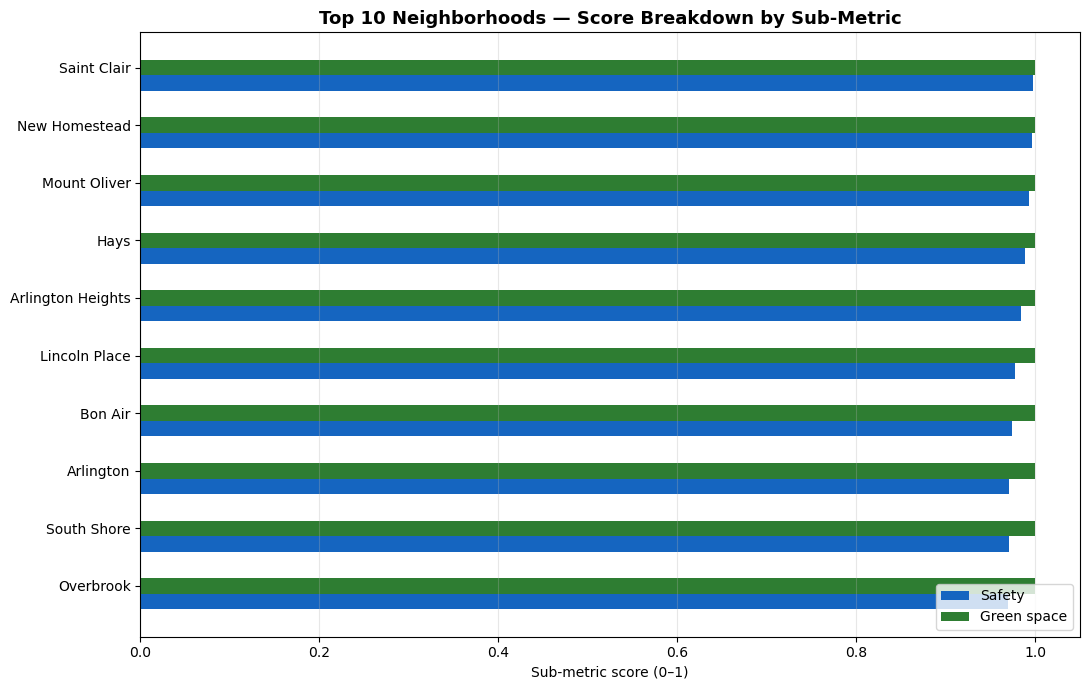

In [22]:
top10 = ranked.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(top10))
width = 0.27

ax.barh(y - width, top10['safety_score'], width, label = 'Safety', color = '#1565C0')
ax.barh(y,        top10['green_score'],  width, label = 'Green space', color = '#2E7D32')
#ax.barh(y,        top10['accessibility_score'],  width, label='Accessibility', color='red')

ax.set_yticks(y)
ax.set_yticklabels(top10['neighborhood'])
ax.set_xlabel('Sub-metric score (0–1)')
ax.set_xlim(0, 1.05)
ax.set_title('Top 10 Neighborhoods — Score Breakdown by Sub-Metric', fontsize = 13, fontweight = 'bold')
ax.legend(loc = 'lower right')
ax.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

In [11]:
ranked.to_csv('final_rankings.csv', index=False)
print(f'Saved final_rankings.csv with {len(ranked)} ranked neighborhoods.')

Saved final_rankings.csv with 79 ranked neighborhoods.


### Limitations

> Geographic mismatch - The parks dataset only labels parks by maintenance division, so it requires mapping each division's score to its respective neighborhoods. This means every neighborhood within the same division receives the same green space score, even though in reality a neighborhood right next to a regional park has very different access than one on the division's edge. <br>

> Snapshot data - Arrest data covers 2024 to early 2026, parks data is a current snapshot. A one-year window can be biased by short-term spikes. <br>

> **Arrests ≠ crime - Arrest counts measure police activity, not crime itself. A heavily-policed neighborhood may show more arrests not because it's less safe but because it gets more attention.